# 07 – Modelling: Comparación de Modelos

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024  
**Target:** `target_subempleo_horas` (1 = subempleado por horas, 0 = no subempleado)

Este notebook consolida las métricas de todos los modelos entrenados en los notebooks anteriores, los rankea por **F1-score** y **Recall de la clase 1** (subempleados), y selecciona el modelo ganador, que se guarda como `best_model.pkl`.

> **Prerequisito:** Deben haberse ejecutado `baseline_model.ipynb` y `decision_tree_or_random_forest.ipynb` para generar los archivos de métricas y modelos.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
import joblib
import os 

from sklearn.metrics import roc_curve, roc_auc_score

pd.set_option("display.max_columns", 50)
print("Librerías importadas.")

Librerías importadas.


## 1. Carga de Métricas

In [3]:
SELECTED_DIR = Path("../data/selected")
RESULTS_DIR  = Path("../data/results")
MODELS_DIR   = Path("../models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_COLS = [
    "model_name", "model_type", "uses_class_weight",
    "accuracy", "precision_0", "recall_0", "f1_0",
    "precision_1", "recall_1", "f1_1", "roc_auc",
]

def _load_metrics(path, label):
    if not path.exists():
        raise FileNotFoundError(
            f"Archivo no encontrado: {path}\n"
            f"Primero debe ejecutarse {label}"
        )
    df = pd.read_csv(path)
    for col in REQUIRED_COLS:
        if col not in df.columns:
            df[col] = np.nan
    return df[REQUIRED_COLS]

df_base  = _load_metrics(RESULTS_DIR / "baseline_model_metrics.csv",
                         "07_modelling/baseline_model.ipynb")
df_trees = _load_metrics(RESULTS_DIR / "tree_models_metrics.csv",
                         "07_modelling/decision_tree_or_random_forest.ipynb")

results_df = pd.concat([df_base, df_trees], ignore_index=True)

TARGET_COL = "target_subempleo_horas"
X_test = pd.read_csv(SELECTED_DIR / "X_test_selected.csv")

def load_target(path):
    df = pd.read_csv(path)
    if TARGET_COL in df.columns:
        return df[TARGET_COL].reset_index(drop=True)
    if df.shape[1] == 1:
        return df.iloc[:, 0].reset_index(drop=True)
    raise ValueError(f"No se encontró '{TARGET_COL}' en {path}")

y_test = load_target(SELECTED_DIR / "y_test_selected.csv")

print(f"Total de modelos cargados: {len(results_df)}")
print(results_df[["model_name", "f1_1", "recall_1", "roc_auc"]].to_string(index=False))

Total de modelos cargados: 9
                                   model_name   f1_1  recall_1  roc_auc
                        Dummy (most_frequent) 0.0000    0.0000   0.5000
           Logistic Regression (sin balanceo) 0.2995    0.1920   0.6967
Logistic Regression (class_weight='balanced') 0.4746    0.5693   0.6972
                         Decision Tree (base) 0.3481    0.3531   0.5642
                     Decision Tree (balanced) 0.3520    0.3523   0.5686
                 Decision Tree (GridSearchCV) 0.4594    0.5200   0.6860
                         Random Forest (base) 0.3237    0.2237   0.6554
                     Random Forest (balanced) 0.2951    0.1978   0.6529
                 Random Forest (GridSearchCV) 0.4542    0.4633   0.6921


## 2. Ranking de Modelos

In [4]:
# Ranking principal: F1-score clase 1 → Recall clase 1 → ROC-AUC
# Se prioriza la detección de subempleados (clase minoritaria) sobre la Accuracy global.
ranking = (
    results_df
    .sort_values(["f1_1", "recall_1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1  # posición 1-based

print("Ranking de modelos (prioridad: F1-score clase 1):")
print(
    ranking[["model_name", "accuracy", "recall_1", "precision_1", "f1_1", "roc_auc"]]
    .to_string()
)
print(f"\nModelo ganador : {ranking.iloc[0]['model_name']}")
print(f"  F1-clase 1   : {ranking.iloc[0]['f1_1']:.4f}")
print(f"  Recall-clase1: {ranking.iloc[0]['recall_1']:.4f}")
print(f"  ROC-AUC      : {ranking.iloc[0]['roc_auc']:.4f}")

Ranking de modelos (prioridad: F1-score clase 1):
                                      model_name  accuracy  recall_1  precision_1    f1_1  roc_auc
1  Logistic Regression (class_weight='balanced')    0.6861    0.5693       0.4069  0.4746   0.6972
2                   Decision Tree (GridSearchCV)    0.6953    0.5200       0.4115  0.4594   0.6860
3                   Random Forest (GridSearchCV)    0.7227    0.4633       0.4454  0.4542   0.6921
4                       Decision Tree (balanced)    0.6770    0.3523       0.3517  0.3520   0.5686
5                           Decision Tree (base)    0.6708    0.3531       0.3433  0.3481   0.5642
6                           Random Forest (base)    0.7672    0.2237       0.5852  0.3237   0.6554
7             Logistic Regression (sin balanceo)    0.7763    0.1920       0.6805  0.2995   0.6967
8                       Random Forest (balanced)    0.7647    0.1978       0.5809  0.2951   0.6529
9                          Dummy (most_frequent)    0.7510 

## 3. Comparación Visual

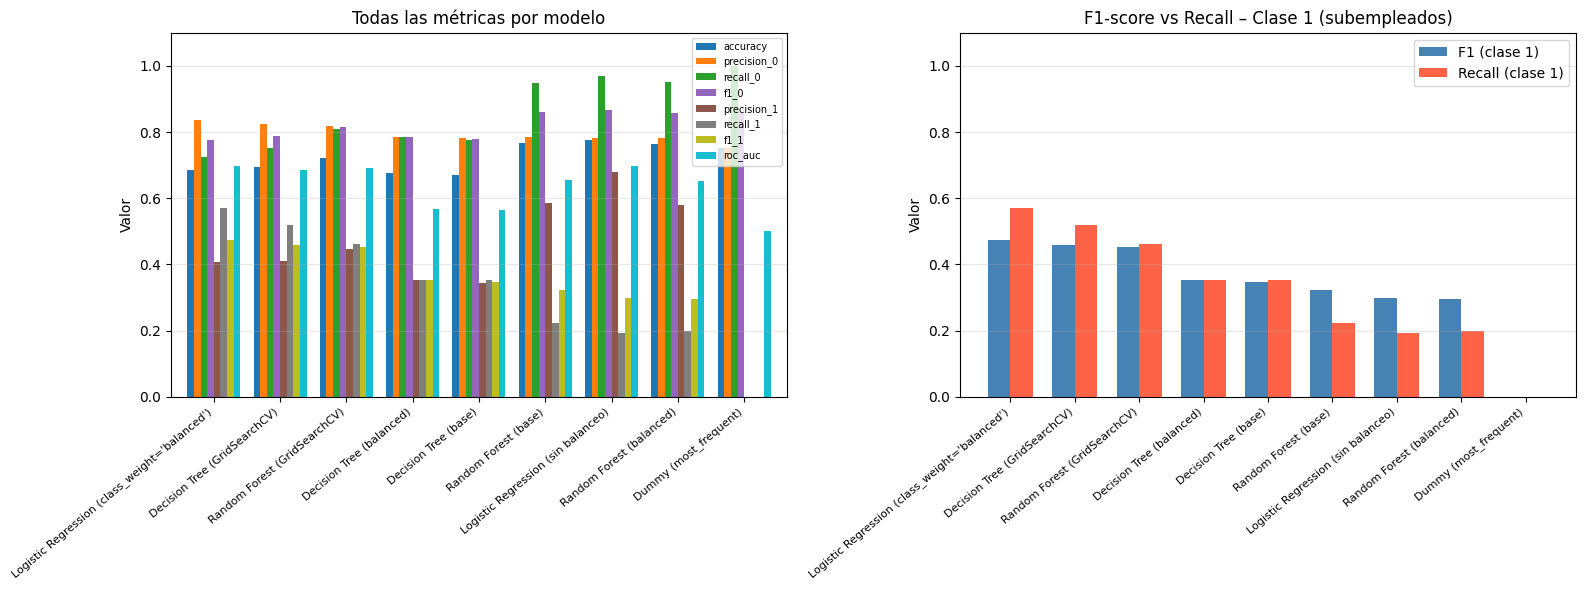

In [5]:
metric_cols = ["accuracy", "precision_0", "recall_0", "f1_0",
               "precision_1", "recall_1", "f1_1", "roc_auc"]

plot_df = ranking.copy()
plot_df = plot_df.melt(
    id_vars="model_name",
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo – todas las métricas por modelo
ax = axes[0]
pivot = ranking.set_index("model_name")[metric_cols]
pivot.plot(kind="bar", ax=ax, colormap="tab10", width=0.8)
ax.set_title("Todas las métricas por modelo")
ax.set_xlabel("")
ax.set_ylabel("Valor")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
ax.legend(loc="upper right", fontsize=7)
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

# Panel derecho – F1 vs Recall clase 1
ax2 = axes[1]
x = np.arange(len(ranking))
w = 0.35
ax2.bar(x - w/2, ranking["f1_1"],     width=w, label="F1 (clase 1)",     color="steelblue")
ax2.bar(x + w/2, ranking["recall_1"], width=w, label="Recall (clase 1)", color="tomato")
ax2.set_xticks(x)
ax2.set_xticklabels(ranking["model_name"], rotation=40, ha="right", fontsize=8)
ax2.set_title("F1-score vs Recall – Clase 1 (subempleados)")
ax2.set_ylabel("Valor")
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Curvas ROC Comparativas

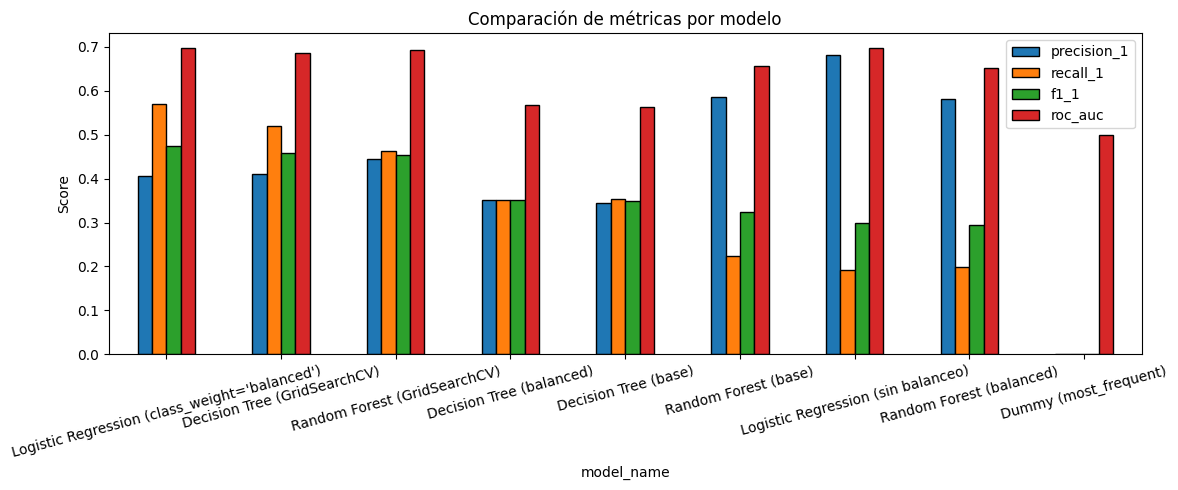

In [9]:
metrics_plot = ['precision_1', 'recall_1', 'f1_1', 'roc_auc']
ranking.set_index('model_name')[metrics_plot].plot(
    kind='bar', figsize=(12, 5), edgecolor='black'
)
plt.title('Comparación de métricas por modelo')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar tabla de resultados
os.makedirs(os.path.join('..', 'data', 'results'), exist_ok=True)
results_df.to_csv(os.path.join('..', 'data', 'results', 'model_comparison.csv'), index=False)
print('Tabla guardada: data/results/model_comparison.csv')
print(f'\n Modelo ganador: {ranking.iloc[0]["model_name"]} (AUC={ranking.iloc[0]["roc_auc"]:.3f})')

Tabla guardada: data/results/model_comparison.csv

 Modelo ganador: Logistic Regression (class_weight='balanced') (AUC=0.697)
